# Data Loading

In [41]:
import re
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [42]:
def extract_matrix_block(lines, varname):
    in_block = False
    matrix_lines = []

    for line in lines:
        if line.strip().startswith(f"{varname} = ["):
            in_block = True
            continue
        if in_block:
            if line.strip().startswith("];"):
                break
            clean = re.sub(r'%.*', '', line).strip().rstrip(';')
            if clean:
                matrix_lines.append(clean)

    matrix_data = []
    for line in matrix_lines:
        row = [float(x) for x in line.split()]
        matrix_data.append(row)
    
    return np.array(matrix_data)

# Load m file path
path = 'data/pglib_opf_case14_ieee.m'

with open(path, 'r') as f:
    lines = f.readlines()

bus = extract_matrix_block(lines, 'mpc.bus')
branch = extract_matrix_block(lines, 'mpc.branch')
gen = extract_matrix_block(lines, 'mpc.gen')
gencost = extract_matrix_block(lines, 'mpc.gencost')

bus_df = pd.DataFrame(bus, columns=[
    'bus_i','type','Pd','Qd','Gs','Bs','area','Vm','Va','baseKV','zone','Vmax','Vmin'
])
gen_df = pd.DataFrame(gen, columns=[
    'bus','Pg','Qg','Qmax','Qmin','Vg','mBase','status','Pmax','Pmin'
])
branch_df = pd.DataFrame(branch, columns=[
    'fbus','tbus','r','x','b','rateA','rateB','rateC',
    'ratio','angle','status','angmin','angmax'
])
gencost_df = pd.DataFrame(gencost, columns=[
    'model','startup','shutdown','n','c2','c1','c0'
])


In [43]:
bus_df

,bus_i,type,Pd,Qd,Gs,Bs,area,Vm,Va,baseKV,zone,Vmax,Vmin
0,1.0,3.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
1,2.0,2.0,21.7,12.7,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
2,3.0,2.0,94.2,19.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
3,4.0,1.0,47.8,-3.9,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
4,5.0,1.0,7.6,1.6,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
5,6.0,2.0,11.2,7.5,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
6,7.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
7,8.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
8,9.0,1.0,29.5,16.6,0.0,19.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
9,10.0,1.0,9.0,5.8,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94


In [45]:
gen_df

,bus,Pg,Qg,Qmax,Qmin,Vg,mBase,status,Pmax,Pmin
0,1.0,170.0,5.0,10.0,0.0,1.0,100.0,1.0,340.0,0.0
1,2.0,29.5,0.0,30.0,-30.0,1.0,100.0,1.0,59.0,0.0
2,3.0,0.0,20.0,40.0,0.0,1.0,100.0,1.0,0.0,0.0
3,6.0,0.0,9.0,24.0,-6.0,1.0,100.0,1.0,0.0,0.0
4,8.0,0.0,9.0,24.0,-6.0,1.0,100.0,1.0,0.0,0.0


In [46]:
gencost_df

,model,startup,shutdown,n,c2,c1,c0
0,2.0,0.0,0.0,3.0,0.0,7.920951,0.0
1,2.0,0.0,0.0,3.0,0.0,23.269494,0.0
2,2.0,0.0,0.0,3.0,0.0,0.000000,0.0
3,2.0,0.0,0.0,3.0,0.0,0.000000,0.0
4,2.0,0.0,0.0,3.0,0.0,0.000000,0.0


In [47]:
branch_df

,fbus,tbus,r,x,b,rateA,rateB,rateC,ratio,angle,status,angmin,angmax
0,1.0,2.0,0.01938,0.05917,0.0528,472.0,472.0,472.0,0.000,0.0,1.0,-30.0,30.0
1,1.0,5.0,0.05403,0.22304,0.0492,128.0,128.0,128.0,0.000,0.0,1.0,-30.0,30.0
2,2.0,3.0,0.04699,0.19797,0.0438,145.0,145.0,145.0,0.000,0.0,1.0,-30.0,30.0
3,2.0,4.0,0.05811,0.17632,0.0340,158.0,158.0,158.0,0.000,0.0,1.0,-30.0,30.0
4,2.0,5.0,0.05695,0.17388,0.0346,161.0,161.0,161.0,0.000,0.0,1.0,-30.0,30.0
5,3.0,4.0,0.06701,0.17103,0.0128,160.0,160.0,160.0,0.000,0.0,1.0,-30.0,30.0
6,4.0,5.0,0.01335,0.04211,0.0000,664.0,664.0,664.0,0.000,0.0,1.0,-30.0,30.0
7,4.0,7.0,0.00000,0.20912,0.0000,141.0,141.0,141.0,0.978,0.0,1.0,-30.0,30.0
8,4.0,9.0,0.00000,0.55618,0.0000,53.0,53.0,53.0,0.969,0.0,1.0,-30.0,30.0
9,5.0,6.0,0.00000,0.25202,0.0000,117.0,117.0,117.0,0.932,0.0,1.0,-30.0,30.0


# optimization model

In [48]:
def define_dc_opf_model(bus_df, branch_df, gen_df, gencost_df):
    model = gp.Model("DC-OPF")

    # Sets
    buses = bus_df['bus_i'].values
    branches = branch_df.index
    generators = gen_df.index

    # Parameters
    bus_map = dict(zip(bus_df['bus_i'], range(len(bus_df))))

    Pd = dict(zip(bus_df['bus_i'], bus_df['Pd']))
    gen_at_bus = {bus: gen_df[gen_df['bus'] == bus].index.tolist() for bus in bus_df['bus_i']}

    # Decision variables
    Pg = model.addVars(generators, name="Pg")
    theta = model.addVars(buses, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="theta")
    #theta = model.addVars(buses, lb=-np.pi, ub=np.pi, name="theta")  
    P_line = model.addVars(branches, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="P_line")

    # Objective: generation cost
    obj = gp.QuadExpr()
    for i in generators:
        c2 = gencost_df.loc[i, 'c2']
        c1 = gencost_df.loc[i, 'c1']
        c0 = gencost_df.loc[i, 'c0']
        obj += c2 * Pg[i] * Pg[i] + c1 * Pg[i] + c0
    model.setObjective(obj, GRB.MINIMIZE)

    # Reference bus angle
    ref_bus = bus_df[bus_df['type'] == 3]['bus_i'].values[0]
    model.addConstr(theta[ref_bus] == 0, name="reference_bus")

    # Power balance constraints
    for bus in buses:
        gen_sum = gp.quicksum(Pg[g] for g in gen_at_bus[bus]) if gen_at_bus[bus] else 0
        load = Pd[bus]
        inflow = gp.quicksum(P_line[l] for l in branch_df[(branch_df['tbus'] == bus)].index)
        outflow = gp.quicksum(P_line[l] for l in branch_df[(branch_df['fbus'] == bus)].index)
        model.addConstr(gen_sum - load + inflow - outflow == 0, name=f"power_balance_{bus}")

    # Branch power flow constraints: P = (theta_i - theta_j) / x
    for idx, row in branch_df.iterrows():
        i = row['fbus']
        j = row['tbus']
        x = row['x']
        rateA = row['rateA']
        if rateA > 0:
            model.addConstr((theta[i] - theta[j]) / x <= rateA, name=f"line_max_{idx}")
            model.addConstr((theta[i] - theta[j]) / x >= -rateA, name=f"line_min_{idx}")
        model.addConstr(P_line[idx] == (theta[i] - theta[j]) / x, name=f"flow_eq_{idx}")

    # Generator limits
    for idx, row in gen_df.iterrows():
        model.addConstr(Pg[idx] >= row['Pmin'], name=f"Pg_min_{idx}")
        model.addConstr(Pg[idx] <= row['Pmax'], name=f"Pg_max_{idx}")

    return model, Pg, theta, P_line, Pd

In [49]:
model, Pg_base, theta_base, P_line_base, Pd_base = define_dc_opf_model(bus_df, branch_df, gen_df, gencost_df)
model.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 23.6.0 23H420)

CPU model: Apple M2 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerprint: 0x1e6c3824
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [8e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 7e+02]
Presolve removed 74 rows and 33 columns
Presolve time: 0.01s
Presolved: 11 rows, 12 columns, 37 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
       4    2.0515263e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.01 seconds (0.00 work units)
Optimal objective  2.051526309e+03


# visualize

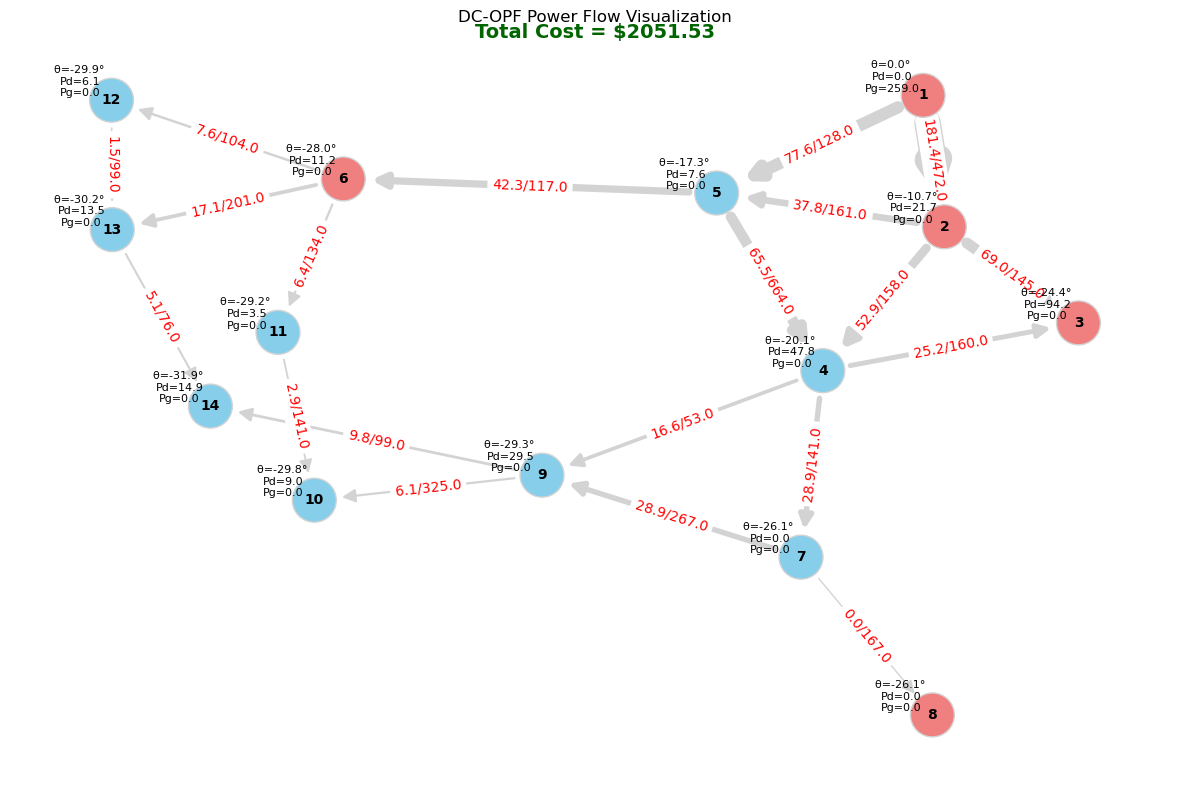

In [50]:
# 构建图
G = nx.Graph()
for _, row in bus_df.iterrows():
    G.add_node(int(row['bus_i']))
for _, row in branch_df.iterrows():
    G.add_edge(int(row['fbus']), int(row['tbus']))

# 获取节点坐标布局
pos = nx.spring_layout(G, seed=42)

# Draw node
gen_buses = set(gen_df['bus'].astype(int))
node_colors = ['lightcoral' if node in gen_buses else 'skyblue' for node in G.nodes]

# Draw base graph
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color=node_colors, edgecolors='lightgray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw power flow on edges
edge_labels = {}
edge_widths = []
edge_list = []

for idx, row in branch_df.iterrows():
    fbus = int(row['fbus'])
    tbus = int(row['tbus'])
    flow = P_line_base[idx].X
    rateA = int(row['rateA'])
    width = 1 + 0.1 * abs(flow)

    if flow >= 0:
        edge_list.append((fbus, tbus))
        edge_labels[(fbus, tbus)] = f"{flow:.1f}/{rateA:.1f}"
    else:
        edge_list.append((tbus, fbus))
        edge_labels[(tbus, fbus)] = f"{-flow:.1f}/{rateA:.1f}"

    edge_widths.append(width)

nx.draw_networkx_edges(
    G, pos, edgelist=edge_list,
    width=edge_widths,
    edge_color='lightgray', arrows=True, arrowstyle='-|>', 
    arrowsize=20,
    min_source_margin=20,  
    min_target_margin=20
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10)


# Display Pg next to nodes
for bus in bus_df['bus_i']:
    Pg = sum(Pg_base[g].X for g in Pg_base if gen_df.loc[g, 'bus'] == bus)
    Pd = Pd_base[bus]
    theta_val = theta_base[bus].X
    x, y = pos[bus]
    plt.text(x - 0.05, y + 0.01, f"θ={theta_val:.1f}° \nPd={Pd}\nPg={Pg:.1f}", fontsize=8, ha='center')

plt.title("DC-OPF Power Flow Visualization")

# Total Cost
total_cost_b = model.ObjVal
plt.text(0.5, 0.99, f"Total Cost = ${round(total_cost_b,2)}", fontsize=14,
         color='darkgreen', ha='center', fontweight='bold', transform=plt.gca().transAxes)

plt.axis('off')
plt.tight_layout()
plt.show()


# Generating Data

In [ ]:
X_base = list(Pd_base.values())

Pg_base = [Pg_base[k].X for k in Pg_base]
theta_base = [theta_base[k].X for k in theta_base]
P_line_base = [P_line_base[k].X for k in P_line_base]
total_cost_b = model.ObjVal

Y_base = Pg_base + theta_base + P_line_base + [total_cost_b]

In [ ]:
# perturb pd′=s⋅pd+ϵ,where s∼Uniform(0.8,1.0),ϵ∼Uniform(−0.05⋅pd,+0.05⋅pd)

base_Pd = bus_df['Pd'].values
N = 1000
np.random.seed(42) 

# Generate s ∈ [0.8, 1.0] for each sample
s_samples = np.random.uniform(0.8, 1.0, size=(N, 1)) 

base_Pd_matrix = np.tile(base_Pd, (N, 1))  # shape: (N, num_buses)

# Generate ε ∈ [−0.05*Pd, 0.05*Pd]
epsilons = (np.random.rand(N, len(base_Pd)) - 0.5) * 0.1 * base_Pd_matrix 

pd_samples = s_samples * base_Pd_matrix + epsilons 

In [ ]:
X_list = []
Y_list = []

not_optimal_list = []
failed_sample_list = []

for i in range(N):
    pd_sample = pd_samples[i]
    
    perturbed_bus_df = bus_df.copy()
    perturbed_bus_df['Pd'] = pd_sample

    try:
        model, Pg, theta, P_line, Pd = define_dc_opf_model(perturbed_bus_df, branch_df, gen_df, gencost_df)
        model.optimize()

        if model.status == gp.GRB.OPTIMAL:
            # input
            input_vector = pd_sample.tolist()
            X_list.append(input_vector)

            # optimal solution
            Pg_sol = {k: Pg[k].X for k in Pg.keys()}
            theta_sol = {i: theta[i].X for i in theta.keys()}
            P_line_sol = {i: P_line[i].X for i in P_line.keys()}

            # optimal value
            total_cost = model.ObjVal

            # output
            Y_sample = (
                list(Pg_sol.values()) +
                list(theta_sol.values()) +
                list(P_line_sol.values()) +
                [model.ObjVal]
            )
            Y_list.append(Y_sample)

        else:
            print(f"Sample {i} not optimal. Status = {model.status}")
            not_optimal_list.append(i)

    except Exception as e:
        print(f"Sample {i} failed due to error: {e}")
        failed_sample_list.append(i)


Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.2.0 23C71)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerprint: 0x85384235
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [8e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 7e+02]
Presolve removed 74 rows and 33 columns
Presolve time: 0.00s
Presolved: 11 rows, 12 columns, 37 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
       4    1.8304624e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.830462402e+03
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.2.0 23C71)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up

Optimal objective  1.915979862e+03
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.2.0 23C71)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerprint: 0xce9c608f
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [8e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 7e+02]
Presolve removed 74 rows and 33 columns
Presolve time: 0.00s
Presolved: 11 rows, 12 columns, 37 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
       4    1.6820331e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.682033138e+03
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.2.0 23C71)

CPU model: Apple M1
Thread count: 8 physical co


Solved in 4 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.758841036e+03
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.2.0 23C71)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerprint: 0xbdf8cf63
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [8e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 7e+02]
Presolve removed 74 rows and 33 columns
Presolve time: 0.00s
Presolved: 11 rows, 12 columns, 37 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
       4    1.8677357e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.867735725e+03
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.

       4    1.6859799e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.685979923e+03
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.2.0 23C71)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerprint: 0x1c8654ce
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [8e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 7e+02]
Presolve removed 74 rows and 33 columns
Presolve time: 0.00s
Presolved: 11 rows, 12 columns, 37 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
       4    1.8578334e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.857833432e+03
Gurobi Optimiz

       0      handle free variables                          0s
       4    1.7970995e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.797099547e+03
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.2.0 23C71)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerprint: 0x7f886bc1
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [8e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 7e+02]
Presolve removed 74 rows and 33 columns
Presolve time: 0.00s
Presolved: 11 rows, 12 columns, 37 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
       4    1.7084431e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.00 seconds (0.

...


CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerprint: 0x370b4728
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [8e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 7e+02]
Presolve removed 74 rows and 33 columns
Presolve time: 0.00s
Presolved: 11 rows, 12 columns, 37 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
       4    1.8849629e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.884962925e+03
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.2.0 23C71)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerpri

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)




CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerprint: 0xc7249142
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [8e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 7e+02]
Presolve removed 74 rows and 33 columns
Presolve time: 0.00s
Presolved: 11 rows, 12 columns, 37 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
       4    1.6490884e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.649088367e+03
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.2.0 23C71)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerpri


CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerprint: 0xb0d741ed
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [8e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 7e+02]
Presolve removed 74 rows and 33 columns
Presolve time: 0.00s
Presolved: 11 rows, 12 columns, 37 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
       4    1.7888107e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.788810735e+03
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.2.0 23C71)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerpri


CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerprint: 0x38fd380b
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [8e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 7e+02]
Presolve removed 74 rows and 33 columns
Presolve time: 0.00s
Presolved: 11 rows, 12 columns, 37 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
       4    1.7073317e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.707331685e+03
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[rosetta2] - Darwin 23.2.0 23C71)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 85 rows, 39 columns and 196 nonzeros
Model fingerpri

In [ ]:
not_optimal_list, failed_sample_list

([], [])

In [ ]:
# input variable
X_columns = (
    [f'Pd_bus{i+1}' for i in range(len(base_Pd))]
)

# output variable
Y_columns = (
    [f'Pg_gen{i+1}' for i in range(len(gen_df))] +
    [f'theta{i+1}' for i in range(len(bus_df))] +
    [f'branch{i+1}' for i in range(len(branch_df))] +
    ['Total_Cost']
)

X_df = pd.DataFrame(X_list, columns=X_columns)
Y_df = pd.DataFrame(Y_list, columns=Y_columns)

dataset_df = pd.concat([X_df, Y_df], axis=1)
dataset_df.to_csv("opf_dataset.csv", index=False)
print("The dataset has been successfully saved as opf_dataset.csv")

The dataset has been successfully saved as opf_dataset.csv


# Stats Description

In [ ]:
base_row = X_base + Y_base
dataset_df.loc[-1] = base_row
dataset_df.index = dataset_df.index + 1  
dataset_df = dataset_df.sort_index() 
dataset_df

,Pd_bus1,Pd_bus2,Pd_bus3,Pd_bus4,Pd_bus5,Pd_bus6,Pd_bus7,Pd_bus8,Pd_bus9,Pd_bus10,...,branch12,branch13,branch14,branch15,branch16,branch17,branch18,branch19,branch20,Total_Cost
0,0.0,21.700000,94.200000,47.800000,7.600000,11.200000,0.0,0.0,29.500000,9.000000,...,7.561230,17.089959,0.0,28.869518,6.085721,9.848811,-2.914279,1.461230,5.051189,2051.526309
1,0.0,19.076429,85.929486,42.930638,6.882287,9.976807,0.0,0.0,25.071307,7.864655,...,6.794835,15.123445,0.0,24.842640,5.549017,8.476750,-2.315638,1.160419,3.873125,1830.462402
2,0.0,22.408889,90.262477,47.653607,7.840857,10.567620,0.0,0.0,30.461183,9.335238,...,7.655727,17.536905,0.0,29.592650,6.157701,9.953704,-3.177537,1.631585,5.312803,2038.038512
3,0.0,21.250600,84.789378,45.698032,6.987438,10.174701,0.0,0.0,27.446395,8.719879,...,7.144514,16.306829,0.0,27.231446,5.836924,9.573233,-2.882955,1.484154,4.961286,1910.939490
4,0.0,20.231362,90.274636,44.517001,6.787010,9.768324,0.0,0.0,28.237455,8.303629,...,7.194058,16.277204,0.0,27.071396,5.475701,8.891510,-2.827927,1.401437,4.590053,1931.562910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,0.0,17.762960,77.662622,38.339997,5.893659,9.661868,0.0,0.0,23.747596,7.599596,...,5.964850,13.486001,0.0,23.400041,5.218309,7.860824,-2.381287,1.155459,4.101217,1670.045071
997,0.0,22.422385,88.395548,46.728184,7.437908,10.791490,0.0,0.0,29.849692,8.700367,...,7.656138,17.374905,0.0,29.062703,5.833383,10.055490,-2.866985,1.525476,5.098428,2003.099174
998,0.0,17.711606,77.967851,40.832538,6.574899,8.822709,0.0,0.0,24.205603,7.295279,...,6.410248,14.583315,0.0,23.786474,4.951774,8.277517,-2.343505,1.300594,4.039762,1707.331685
999,0.0,20.752407,88.951406,47.605415,7.558236,10.758394,0.0,0.0,28.495740,8.770117,...,7.481363,17.021416,0.0,28.275932,6.145808,9.858803,-2.624309,1.518772,4.822465,1987.288417


In [ ]:
# Define index ranges
i = 0

df = dataset_df
N_bus = len(bus_df)
N_gen = len(gen_df)
N_branch = len(branch_df)

# --- Input features ---
Pd = df.iloc[:, i : i + N_bus];         i += N_bus

X = Pd

# --- Output variables ---
Pg = df.iloc[:, i : i + N_gen];         i += N_gen
theta = df.iloc[:, i : i + N_bus];     i += N_bus
branch = df.iloc[:, i : i + N_branch]; i += N_branch
Cost = df.iloc[:, i]  # final column

Y = pd.concat([
    Pg, theta, branch, Cost
], axis=1)


In [ ]:
def describe_perturbed_variables(data: pd.DataFrame, label="Y"):
    base = data.iloc[0]
    perturbed = data.iloc[1:]

    summary = pd.DataFrame({
        "Base": base,
        "Mean": perturbed.mean(),
        "Std": perturbed.std(),
        "Min": perturbed.min(),
        "Max": perturbed.max(),
        "MinDiff": perturbed.min() - base,
        "MaxDiff": perturbed.max() - base,
        "MeanAbsDev": (perturbed - base).abs().mean()
    })

    return summary

In [ ]:
X_summary = describe_perturbed_variables(X, label="X")
X_summary

,Base,Mean,Std,Min,Max,MinDiff,MaxDiff,MeanAbsDev
Pd_bus1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Pd_bus2,21.7,19.474968,1.425073,16.394173,22.633057,-5.305827,0.933057,2.270158
Pd_bus3,94.2,84.579728,5.996404,70.891090,98.579973,-23.308910,4.379973,9.816064
Pd_bus4,47.8,42.880603,3.105862,36.202274,49.968169,-11.597726,2.168169,5.012969
Pd_bus5,7.6,6.819194,0.503531,5.745835,7.932257,-1.854165,0.332257,0.797277
Pd_bus6,11.2,10.047560,0.746113,8.497018,11.710252,-2.702982,0.510252,1.176228
Pd_bus7,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Pd_bus8,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Pd_bus9,29.5,26.485328,1.909799,22.333559,30.784101,-7.166441,1.284101,3.068339
Pd_bus10,9.0,8.090474,0.577726,6.815703,9.373828,-2.184297,0.373828,0.926550


In [ ]:
Y_summary = describe_perturbed_variables(Y, label="Y")
Y_summary

,Base,Mean,Std,Min,Max,MinDiff,MaxDiff,MeanAbsDev
Pg_gen1,259.000000,232.491441,15.354084,201.437341,265.140761,-57.562659,6.140761,26.597489
Pg_gen2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Pg_gen3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Pg_gen4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Pg_gen5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
theta1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
theta2,-10.733534,-9.635017,0.637049,-10.995166,-8.337486,-0.261632,2.396048,1.102503
theta3,-24.384853,-21.890853,1.465013,-25.163674,-18.758041,-0.778822,5.626811,2.510531
theta4,-20.067457,-18.013229,1.189011,-20.543982,-15.605337,-0.476525,4.462120,2.060702
theta5,-17.307541,-15.535910,1.024288,-17.690961,-13.500615,-0.383419,3.806927,1.776775


In [ ]:
# Step 1: base direction and perturbed directions
base_flow = np.sign(branch.iloc[0].values)
perturbed_flows = np.sign(branch.iloc[1:].values)

# Step 2: compute flip matrix
flips = (perturbed_flows != base_flow).astype(int)

# Step 3: compute flip stats
flip_counts = flips.sum(axis=0)
flip_ratios = flip_counts / flips.shape[0]
total_samples = flips.shape[0]

# Step 4: construct direction summary
direction_summary = pd.DataFrame({
    "Branch": branch.columns,
    "Flip Count": flip_counts,
    "Total Samples": total_samples,
    "Flip Ratio": flip_ratios
}).reset_index(drop=True)

# Step 5: join fbus and tbus from branch_df
direction_summary = pd.concat([
    direction_summary,
    branch_df[["fbus", "tbus"]].reset_index(drop=True)
], axis=1)

# Step 6: reorder columns 
direction_summary = direction_summary[[
    "Branch", "fbus", "tbus", "Flip Count", "Total Samples", "Flip Ratio"
]]

direction_summary

,Branch,fbus,tbus,Flip Count,Total Samples,Flip Ratio
0,branch1,1.0,2.0,0,1000,0.0
1,branch2,1.0,5.0,0,1000,0.0
2,branch3,2.0,3.0,0,1000,0.0
3,branch4,2.0,4.0,0,1000,0.0
4,branch5,2.0,5.0,0,1000,0.0
5,branch6,3.0,4.0,0,1000,0.0
6,branch7,4.0,5.0,0,1000,0.0
7,branch8,4.0,7.0,0,1000,0.0
8,branch9,4.0,9.0,0,1000,0.0
9,branch10,5.0,6.0,0,1000,0.0


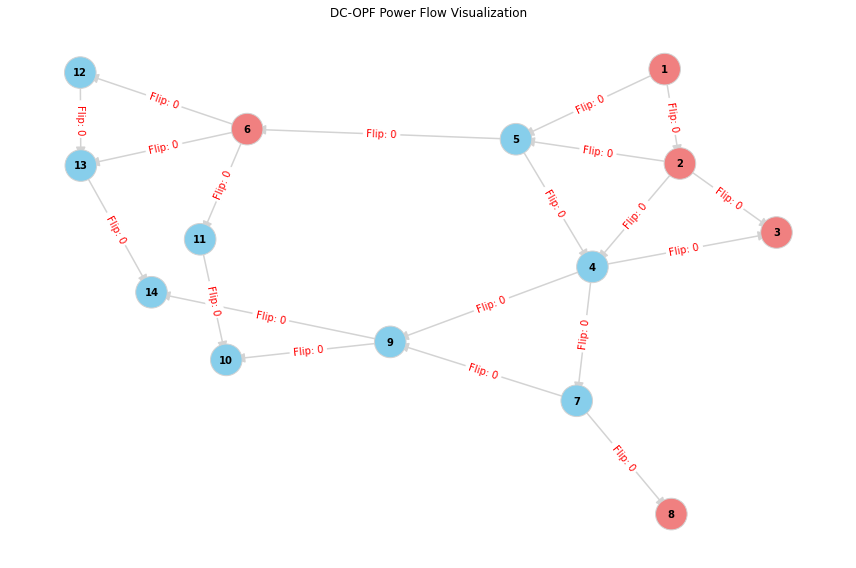

In [ ]:
# 构建图
G = nx.Graph()
for _, row in bus_df.iterrows():
    G.add_node(int(row['bus_i']))
for _, row in branch_df.iterrows():
    G.add_edge(int(row['fbus']), int(row['tbus']))

# 获取节点坐标布局
pos = nx.spring_layout(G, seed=42)

# Draw node
gen_buses = set(gen_df['bus'].astype(int))
node_colors = ['lightcoral' if node in gen_buses else 'skyblue' for node in G.nodes]

# Draw base graph
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color=node_colors, edgecolors='lightgray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw power flow on edges
edge_labels = {}
edge_widths = []
edge_list = []

for idx, row in branch_df.iterrows():
    fbus = int(row['fbus'])
    tbus = int(row['tbus'])
    flow = P_line_base[idx]
    flip = direction_summary.loc[idx, "Flip Count"]

    if flow >= 0:
        edge_list.append((fbus, tbus))
        edge_labels[(fbus, tbus)] = f"Flip: {flip}"
    else:
        edge_list.append((tbus, fbus))
        edge_labels[(tbus, fbus)] = f"Flip: {flip}"

    edge_widths.append(width)

nx.draw_networkx_edges(
    G, pos, edgelist=edge_list,
    width=edge_widths,
    edge_color='lightgray', arrows=True, arrowstyle='-|>', arrowsize=20
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10)


plt.title("DC-OPF Power Flow Visualization")
plt.axis('off')
plt.tight_layout()
plt.show()
